# Source span selection

**Recipe 14** · Level 2 (Easy) · Decision type: `Choice`

Select the supplier name from text spans already extracted by Python, with a not-stated outcome when the document lacks that field.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S06: [TypeSafe AI: Cookbooks](https://docs.typesafe.ai/cookbooks)

## What you will build

A small supplier-name extractor for fabricated purchase documents. Python reads each document and extracts the candidate spans that might name the supplier -- usually one or two short sentences -- before Jev ever sees the document, and assigns each an identifier. Jev reads only those candidate spans, by id, and picks exactly one option: one of this document's own span ids, or the shared fallback `not_stated` for a document that does not name a supplier at all. Python decides nothing about which organisation the text actually names as the supplier; it only decides whether a named pick is confident enough to report the exact span text -- sliced from the document at the offsets Python already recorded, never retyped -- or whether it should go to an explicit review outcome instead, which never happens for `not_stated`, since there is no stored span text a confidence check could protect there. By the end you will have looked at individual typed answers across the range this recipe covers -- a confident, correct pick; a document where the supplier's name appears in two different spans; a confident `not_stated`; and a confident, wrong pick from a near-miss decoy -- then the rule that acts on them, and run an evaluation that chooses its one setting on `validation` and reports exact-match accuracy and `not_stated` handling on `test`. The fixtures hold 40 fabricated documents: 38 are scored (19 `validation`, 19 `test`) and 2 are `demo` only.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 39 distinct stored answers in `fixtures/responses.json` offline (the 40 documents ask 39 distinct questions: the two with no candidate spans at all ask the same empty-candidate question and share one response); setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    confusion_matrix,
    evaluate_outcomes,
    per_class_metrics,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." Offline, a validation number is also a pipeline check: synthetic data checks that
# the pipeline works, and choosing on it is still only a selection step, not a reported result,
# so both labels apply at once and a validation line carries both, in this order.
selection = " (a selection step, not a reported result)"

# Every one of the 40 documents needs at most one request, and the option list (and so the
# question) is built fresh per document from its own candidate spans -- the same consequence
# recipe 07's per-word sense inventory has for its options. This cache makes sure a document
# shown individually and later scored in its split is decided once.
answered = {}


def decide(example):
    if example.id not in answered:
        questions = helpers.build_questions(example.fields)
        state = helpers.build_state(example.fields)
        answered[example.id] = backend.decide(state, questions)["supplier_span"]
    return answered[example.id]


run_header(14, "Source span selection", backend=backend, n_examples=len(scored))

Recipe 14: Source span selection
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `doc_id`, the full `document` text, and the candidate `spans` Python already extracted from it (an id and a character offset pair per span). `build_state` slices each span's exact text out of the document by its offset and passes on only that: a mapping from span id to text. The document itself, the offsets, and `doc_id` all stay in Python; the identifier is attached to the outcome at the end, so it never passes through the model and every result still traces back to its document.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-clear"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "doc_id": "D-DEMO1",
  "document": "Purchase Confirmation #9001. Bill To: Keystone Retail Group, 400 Commerce Ave. Supplier: Granite Hardware Supply, 3 Anvil Row. Items: 50 boxes of wood screws. Thank you for your order.",
  "spans": [
    {
      "id": "s1",
      "start": 29,
      "end": 78
    },
    {
      "id": "s2",
      "start": 79,
      "end": 126
    }
  ]
}
Jev sees:
{
  "spans": {
    "s1": "Bill To: Keystone Retail Group, 400 Commerce Ave.",
    "s2": "Supplier: Granite Hardware Supply, 3 Anvil Row."
  }
}


## The questions

There is one question, and it asks one thing: which candidate span, if any, states who the supplier is? A `Choice` fits because the outcomes are exclusive and Jev should commit to exactly one ([S02](https://docs.typesafe.ai/primitives)). The option list is not the same for every document: Python builds it fresh from this document's own candidate spans (their ids only -- the text already crossed into the state above, so the option itself carries no separate description) plus the shared fallback `not_stated`, built the same way for every document. Because the option set is per-document, so is the replay key: a key computed for one document's spans can never replay for another document's, even one with the same number of candidates ([S06](https://docs.typesafe.ai/cookbooks) covers option selection over a fixed candidate set, built fresh per item, as a worked pattern).

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)` ([S03](https://docs.typesafe.ai/confidence)): 0 when the top option has no more than an even share of the options, 1 when one option holds all the probability. `n` varies by document, from 1 (no candidate spans at all, so the only option is `not_stated`) to the number of extracted spans plus one. A low confidence here does not mean a span is unreadable; it means the top pick did not clear much more than an even share of this document's own options.

In [3]:
fields = demo["d01-clear"].fields
questions = helpers.build_questions(fields)
span = questions["supplier_span"]
print(span.instructions)
for name in span.criteria:
    print(f"  {name}")

Which one of the candidate spans below, if any, states who the supplier is for this purchase -- the party the goods or services were bought from? Choose 'not_stated' if none of them does.
  s1
  s2
  not_stated


## One answer up close

Before any aggregate number, look at four typed answers across the range this recipe covers: a document with one clear "Supplier:" span and a harmless decoy, a document where the supplier's name appears in two different spans, a document with no supporting span at all, and a document whose stored answer is wrong and confident, from a near-miss decoy. The first two and the `not_stated` example come from `validation` or `demo`; the wrong one is a `demo` example, so nothing shown here reaches into a split the evaluation below reports on. Each answer holds the chosen option, a probability for every option, the `confidence` explained above, and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

s1: 'Bill To: Keystone Retail Group, 400 Commerce Ave.'
s2: 'Supplier: Granite Hardware Supply, 3 Anvil Row.'
Choice: s2 (confidence 0.79)
  s2          0.86  #################
  not_stated  0.09  ##
  s1          0.05  #
Provenance: synthetic


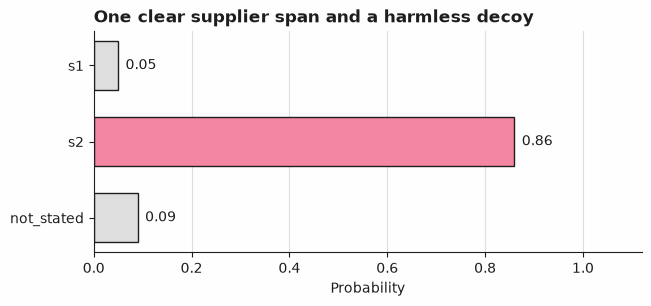

In [4]:
clear_example = demo["d01-clear"]
clear_answer = decide(clear_example)
clear_spans = helpers.spans_by_id(clear_example.fields)
for span_id, text in clear_spans.items():
    print(f"{span_id}: {text!r}")
show_answer(clear_answer)
plot_answer_probabilities(clear_answer, title="One clear supplier span and a harmless decoy")

`s1` is Keystone Retail Group's own `Bill To:` line; `s2` names the supplier directly after a `Supplier:` label. The stored answer puts `s2` on top at 0.86, so `confidence` is 0.79: `(0.86 - 1/3) / (1 - 1/3)`, the published formula with `n = 3` (two candidate spans plus `not_stated`). "Python's part" below will return `s2`'s text -- sliced from the document at its recorded offsets, never retyped -- once a confidence check clears it.

In [5]:
val_examples_preview = select_split(examples, "validation")
twospan_example = next(e for e in val_examples_preview if e.id == "v12")
twospan_answer = decide(twospan_example)
twospan_spans = helpers.spans_by_id(twospan_example.fields)
for span_id, text in twospan_spans.items():
    print(f"{span_id}: {text!r}")
show_answer(twospan_answer)

s1: 'This delivery was prepared by Brightwell Hardware Inc., our supplier of fasteners and tools.'
s2: 'Please remit payment to Brightwell Hardware Inc., Accounts Receivable, 55 Industrial Way.'
Choice: s2 (confidence 0.55)
  s2          0.70  ##############
  s1          0.20  ####
  not_stated  0.10  ##
Provenance: synthetic


Brightwell Hardware Inc. is named twice: `s1` introduces who prepared the delivery, `s2` is the remit-to line. The stored answer puts `s2` on top at 0.70, confidence 0.55. Either span would be an equally correct answer here -- "Python's part" below explains why the rule does not insist on one particular span id when a document states the supplier more than once.

In [6]:
notstated_example = next(e for e in val_examples_preview if e.id == "v14")
notstated_answer = decide(notstated_example)
notstated_spans = helpers.spans_by_id(notstated_example.fields)
for span_id, text in notstated_spans.items():
    print(f"{span_id}: {text!r}")
show_answer(notstated_answer)

s1: 'Bill To: Keystone Retail Group, 400 Commerce Ave.'
s2: 'Shipped via Silverline Freight Services overnight.'
Choice: not_stated (confidence 0.58)
  not_stated  0.72  ##############
  s1          0.14  ###
  s2          0.14  ###
Provenance: synthetic


This delivery note names a buyer (`Bill To: Keystone Retail Group`) and a carrier (`Shipped via Silverline Freight Services`) -- a company mentioned for a reason other than being the supplier, exactly the shape `not_stated` exists to catch. The stored answer puts `not_stated` on top at 0.72, confidence 0.58, but that confidence will turn out not to matter: "Python's part" below reports `not_stated` as a final result whatever its value, because there is no stored span text a confidence check could protect there.

s1: 'Pinehurst Trading Co. handled this kind of delivery under the previous contract.'
s2: 'Hollow Creek Builders Supply has been the supplier since the new agreement took effect, located at 10 Timber Lane.'
Choice: s1 (confidence 0.58)
  s1          0.72  ##############
  s2          0.20  ####
  not_stated  0.08  ##
Provenance: synthetic


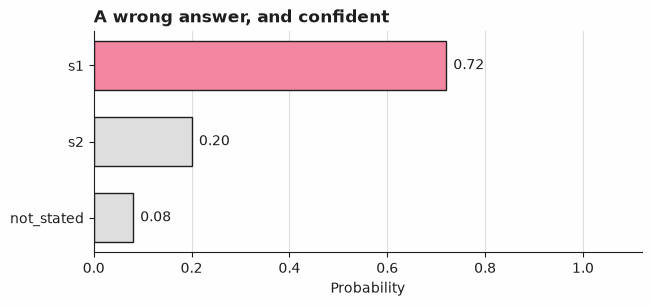

In [7]:
nearmiss_example = demo["d02-near-miss-wrong"]
nearmiss_answer = decide(nearmiss_example)
nearmiss_spans = helpers.spans_by_id(nearmiss_example.fields)
for span_id, text in nearmiss_spans.items():
    print(f"{span_id}: {text!r}")
show_answer(nearmiss_answer)
plot_answer_probabilities(nearmiss_answer, title="A wrong answer, and confident")

"Pinehurst Trading Co. handled this kind of delivery under the previous contract" is a near-miss: same topic (who delivers this kind of order), but it explicitly describes a superseded arrangement, not this shipment's supplier -- that is `s2`, Hollow Creek Builders Supply. The stored answer gets this wrong: `s1` at 0.72, confidence 0.58, comfortably within the range "Python's part" below will treat as confident. This is a `demo` example, so nothing here is scored; it exists to show, before any aggregate number, that a near-miss decoy can out-rank the real supplier and still read as confident -- the same shape `t09` has in `test`, discussed again once the evaluation has reported on it. Nothing here says *why* a real model would get a document like this wrong, because nothing here is a real model: the probabilities were written by hand for this fixture, not produced by Jev.

## Python's part

Jev supplies the pick; what happens with it is code. `select_span` in `helpers.py` returns a confident pick's exact span text, sliced from the document by offset, and decides three things: `not_stated` is reported as a final result whatever its confidence (CONTRIBUTING.md section 4: a low-confidence fallback option may be delivered as a final result instead of going to review when choosing it triggers no side effect, and the notebook says so -- here, choosing `not_stated` routes nothing, answers nothing and moves nothing; there is no stored span text a confidence check could protect, the same reasoning recipe 08's `no_match` uses); a choice naming something other than one of this document's own candidate spans goes to `review` regardless of confidence (defensive, since `build_questions` never offers such an option, but the rule does not trust that silently); and anything else goes to `review` only when its confidence falls below a threshold. `tests/test_helpers.py` checks all three branches, the inclusive boundary, and the error outside `0` to `1`.

Here and below, "gold" means the [gold label](../../docs/glossary.md#gold-label): the correct supplier name, or the literal string `not_stated`, written into `fixtures/labels.jsonl` before this notebook ever runs, never produced by Jev. A document whose supplier's name appears in two spans -- `v12`, `v13`, `t10`, `t11` above and below -- has no single "right" span id: `matches_gold` and `is_correct` check whether the *returned text* contains the gold supplier name, not which id was chosen, so either qualifying span counts as correct. Python's job here is only to assemble candidates and slice text by offset; when a document states the supplier twice, both spans are equally valid evidence, and the evaluation is written to reflect that rather than picking one of them as the sole canonical answer.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest threshold whose accepted subset is perfectly accurate, over the `validation` documents whose raw choice names a real span. Documents whose raw choice is `not_stated` are excluded from this selection on purpose -- `select_span` never applies the threshold to them, so feeding their confidence into the same selection would tune a gate the rule does not have, the same exclusion recipe 08 applies to `no_match`.

In [8]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_spans = [helpers.spans_by_id(e.fields) for e in val_examples]

named = [
    (helpers.matches_gold(a.choice, s, g), a.confidence)
    for a, s, g in zip(val_answers, val_spans, val_gold, strict=True)
    if a.choice != helpers.NOT_STATED
]
named_correct = [c for c, _ in named]
named_confidence = [c for _, c in named]
threshold = select_confidence_threshold(named_correct, named_confidence, target_accuracy=1.0)
print(
    f"chosen threshold, frozen from here on: {threshold:.4f} "
    f"(over {len(named)} named picks in validation, {named_correct.count(False)} of them "
    f"wrong){selection}{check}"
)

for shown_example, shown_answer in (
    (clear_example, clear_answer),
    (twospan_example, twospan_answer),
    (notstated_example, notstated_answer),
    (nearmiss_example, nearmiss_answer),
):
    spans = helpers.spans_by_id(shown_example.fields)
    result = helpers.select_span(shown_example.fields["doc_id"], shown_answer, spans, threshold)
    print(
        f"{result.doc_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.2f} "
        f"-> {result.outcome} ({result.reason})"
    )

chosen threshold, frozen from here on: 0.6400 (over 15 named picks in validation, 1 of them wrong) (a selection step, not a reported result) (a pipeline check, not a Jev result)
D-DEMO1: s2 at confidence 0.79 -> supported (confident match)
D23: s2 at confidence 0.55 -> review (confidence below the threshold)
D27: not_stated at confidence 0.58 -> not_stated (no candidate span supports it)
D-DEMO2: s1 at confidence 0.58 -> review (confidence below the threshold)


## Evaluation

The threshold was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.select_span` is applied to every example in `validation` and in `test`, and the outcome counts below come from what it actually returns, not from a separate reimplementation of the same conditions. **Exact match on the supplier name** is reported two ways: the accuracy of the raw choice before any gate (`matches_gold`, which checks the chosen span's text against the gold name, or `not_stated` against the literal sentinel), and the coverage, accuracy and risk the frozen rule's own outcomes produce (`jev_cookbook.evaluation.evaluate_outcomes`, not `evaluate_selective`: `select_span` has a review branch beyond the confidence gate -- the unconditional `not_stated` branch -- so a generic confidence-only selector would score a gate this rule does not have). **Correct handling of `not_stated`** is reported separately, as a two-class precision and recall between `not_stated` and "names a span", so a mistake in either direction is visible on its own rather than folded into one overall number. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries that label as well.

In [9]:
def report(chosen, decided, gold, spans, threshold):
    """Apply select_span to every answer and tally what it actually did."""
    results = [
        helpers.select_span(e.fields["doc_id"], a, s, threshold)
        for e, a, s in zip(chosen, decided, spans, strict=True)
    ]
    correct = [helpers.is_correct(r, g) for r, g in zip(results, gold, strict=True)]
    counts = {helpers.SUPPORTED: 0, helpers.REVIEW: 0, helpers.NOT_STATED_OUTCOME: 0}
    for r in results:
        counts[r.outcome] += 1
    return results, correct, counts


raw_correct_val = [
    helpers.matches_gold(a.choice, s, g)
    for a, s, g in zip(val_answers, val_spans, val_gold, strict=True)
]
val_results, val_correct, val_counts = report(
    val_examples, val_answers, val_gold, val_spans, threshold
)
print(f"validation, {len(val_examples)} examples{selection}{check}")
print(
    f"accuracy of the raw choice: {sum(raw_correct_val)} of {len(raw_correct_val)} = "
    f"{sum(raw_correct_val) / len(raw_correct_val):.4f}{selection}{check}"
)
print(
    f"supported: {val_counts[helpers.SUPPORTED]}, review: {val_counts[helpers.REVIEW]}, "
    f"not_stated: {val_counts[helpers.NOT_STATED_OUTCOME]} (of {len(val_examples)})"
    f"{selection}{check}"
)
print(f"reviewed in validation, listed individually{selection}{check}:")
for e, r in zip(val_examples, val_results, strict=True):
    if r.outcome == helpers.REVIEW:
        print(f"  {e.id} ({r.doc_id}): chose {r.choice}, sent to review ({r.reason})")

validation, 19 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy of the raw choice: 18 of 19 = 0.9474 (a selection step, not a reported result) (a pipeline check, not a Jev result)
supported: 9, review: 6, not_stated: 4 (of 19) (a selection step, not a reported result) (a pipeline check, not a Jev result)
reviewed in validation, listed individually (a selection step, not a reported result) (a pipeline check, not a Jev result):
  v07 (D13): chose s2, sent to review (confidence below the threshold)
  v08 (D14): chose s2, sent to review (confidence below the threshold)
  v11 (D20): chose s2, sent to review (confidence below the threshold)
  v12 (D23): chose s2, sent to review (confidence below the threshold)
  v13 (D24): chose s1, sent to review (confidence below the threshold)
  v19 (D11): chose s1, sent to review (confidence below the threshold)


Six `validation` documents are reviewed: five of them (`v07`, `v08`, `v11`, `v12`, `v13`) name the right span but too unconfidently to clear the frozen 0.6400, and the sixth, `v19`, is the one answer this recipe places in `validation` on purpose, wrong and confident (`s1`, the shipping-carrier decoy, at confidence 0.6100) -- exactly the error the threshold is chosen to exclude. Without `v19`, every real-span answer in `validation` would already be correct, and `select_confidence_threshold(..., target_accuracy=1.0)` would have nothing to cut on; with it, the threshold has a real wrong answer to exclude, and it does.

In [10]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]
test_spans = [helpers.spans_by_id(e.fields) for e in test_examples]

raw_correct_test = [
    helpers.matches_gold(a.choice, s, g)
    for a, s, g in zip(test_answers, test_spans, test_gold, strict=True)
]
test_results, test_correct, test_counts = report(
    test_examples, test_answers, test_gold, test_spans, threshold
)
print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(
    f"accuracy of the raw choice: {sum(raw_correct_test)} of {len(raw_correct_test)} = "
    f"{sum(raw_correct_test) / len(raw_correct_test):.4f}{check}"
)
print(
    f"supported: {test_counts[helpers.SUPPORTED]}, review: {test_counts[helpers.REVIEW]}, "
    f"not_stated: {test_counts[helpers.NOT_STATED_OUTCOME]} (of {len(test_examples)}){check}"
)
print(f"wrong, but answered anyway{check}:")
for e, r, g in zip(test_examples, test_results, test_gold, strict=True):
    if r.outcome != helpers.REVIEW and not helpers.is_correct(r, g):
        print(f"  {e.id} ({r.doc_id}): {r.outcome} ({r.choice!r}), gold {g!r}{check}")

test, 19 examples, threshold 0.6400 frozen (a pipeline check, not a Jev result)
accuracy of the raw choice: 16 of 19 = 0.8421 (a pipeline check, not a Jev result)
supported: 6, review: 9, not_stated: 4 (of 19) (a pipeline check, not a Jev result)
wrong, but answered anyway (a pipeline check, not a Jev result):
  t09 (D22): supported ('s1'), gold 'Amberline Textiles Co.' (a pipeline check, not a Jev result)
  t14 (D32): not_stated ('not_stated'), gold 'Ashgrove Fixtures Co.' (a pipeline check, not a Jev result)


Three of `test`'s documents are wrong, in three different ways. `t07` (gold `Redstone Analytics Inc.`) is wrong and low-confidence: its raw choice names the decoy bank at confidence 0.1300, well below 0.6400, so it is reviewed rather than reported -- this is the gate doing exactly what it is for. `t09` (gold `Amberline Textiles Co.`) is wrong and confident: the near-miss decoy, the superseded supplier, is chosen at confidence 0.7000, comfortably above the frozen threshold, so the rule accepts it anyway -- a threshold chosen to be perfectly accurate on `validation` is a guarantee about `validation`, not about `test` or about any document this recipe has not seen. `t14` (gold `Ashgrove Fixtures Co.`) is wrong the other way: the stored answer says `not_stated` even though a real supplier is named, and nothing catches it, because `select_span` never applies the confidence gate to `not_stated` at all -- the mistake here is not a threshold failing to catch a wrong answer, it is a wrong answer in a branch that has no threshold to fail.

The `supported`/`review`/`not_stated` counts above come straight from `select_span`. `coverage` is the fraction of documents the rule actually answered -- `supported` or `not_stated`, either one a real result handed back -- rather than held for `review`; among those answered, `accuracy` is the fraction that are right, and `risk` is its complement, `1 - accuracy`, the fraction of answered documents that are wrong despite the rule having delivered a result for them. `jev_cookbook.evaluation.evaluate_outcomes(accepted, correct)` computes all three from the rule's own accept/review decisions, not from a confidence threshold reapplied after the fact: `select_span`'s `not_stated` branch is never gated on confidence, so a generic selective-prediction helper that assumes the gate is the only review branch would score a gate this rule does not have.

In [11]:
val_accepted = [r.outcome != helpers.REVIEW for r in val_results]
val_selective = evaluate_outcomes(val_accepted, val_correct)
print(
    f"validation: answered {val_selective.n_answered} of {val_selective.n_total} "
    f"(coverage {val_selective.coverage:.4f}){selection}{check}"
)
print(f"accuracy among those answered: {val_selective.accuracy:.4f}{selection}{check}")
print(f"risk among those answered: {val_selective.risk:.4f}{selection}{check}")

test_accepted = [r.outcome != helpers.REVIEW for r in test_results]
test_selective = evaluate_outcomes(test_accepted, test_correct)
print()
print(
    f"test: answered {test_selective.n_answered} of {test_selective.n_total} "
    f"(coverage {test_selective.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {test_selective.accuracy:.4f}{check}")
print(f"risk among those answered: {test_selective.risk:.4f}{check}")

validation: answered 13 of 19 (coverage 0.6842) (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy among those answered: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
risk among those answered: 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)

test: answered 10 of 19 (coverage 0.5263) (a pipeline check, not a Jev result)
accuracy among those answered: 0.8000 (a pipeline check, not a Jev result)
risk among those answered: 0.2000 (a pipeline check, not a Jev result)


`validation`'s risk is 0.0000: the only wrong named answer in `validation`, `v19`, is reviewed rather than answered, so nothing wrong is ever reported there -- that is what choosing the threshold on `validation` is supposed to buy, and it does, on this split. `test`'s risk is not zero, at 0.2000: 8 of the 10 answered documents are right. The two wrong, answered documents are `t09` (a confident wrong span the gate let through) and `t14` (a confident wrong `not_stated` the gate was never asked about); `t07`, the third error, is not among them, because it was reviewed rather than answered. Neither frozen number is a guarantee about anything but this fixture set: a threshold chosen on `validation` is a trade-off measured there, not a promise about `test` or about any document this recipe has not seen.

['not_stated', 'named']
[[3, 0], [1, 15]]


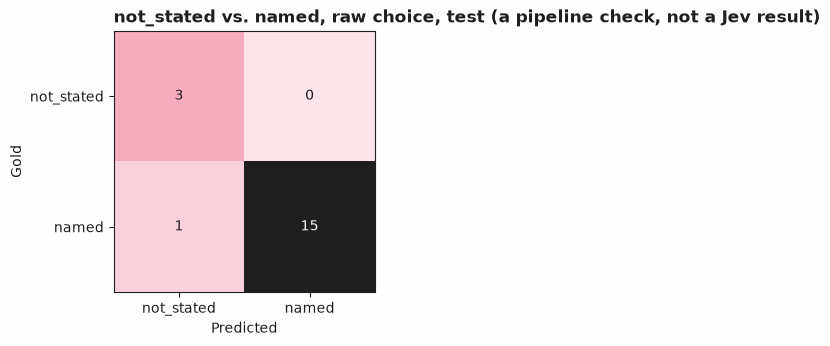

In [12]:
def label_of(choice):
    return helpers.NOT_STATED if choice == helpers.NOT_STATED else "named"


test_gold_labels = [helpers.NOT_STATED if g == helpers.NOT_STATED else "named" for g in test_gold]
test_pred_labels = [label_of(a.choice) for a in test_answers]
matrix = confusion_matrix(test_gold_labels, test_pred_labels, labels=[helpers.NOT_STATED, "named"])
print(matrix.labels)
print(matrix.matrix.tolist())
plot_confusion_matrix(matrix, title=f"not_stated vs. named, raw choice, test{check}")

Rows are the gold label, columns the raw choice, each counted on the same two classes: `not_stated` (the document names no supplier) against "named" (it does). `precision` is the fraction of the rule's raw `not_stated` calls that were actually right, and `recall` is the fraction of the truly-`not_stated` documents the rule actually caught; `f1` is their harmonic mean, a single number that is low whenever either one is, and `support` is how many `test` documents actually carry that gold label.

In [13]:
per_class = per_class_metrics(
    test_gold_labels, test_pred_labels, labels=[helpers.NOT_STATED, "named"]
)
for label, counts in per_class.items():
    print(
        f"{label:10s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )

not_stated precision 0.750  recall 1.000  f1 0.857  support 3 (a pipeline check, not a Jev result)
named      precision 1.000  recall 0.938  f1 0.968  support 16 (a pipeline check, not a Jev result)


`not_stated`'s precision (0.750) is 3 of the 4 documents the rule called `not_stated` that truly had no supplier: the fourth is `t14` above, a real `Ashgrove Fixtures Co.` document the rule misreads as having no supplier at all. Its recall (1.000) is a perfect 3 of 3 -- every truly-`not_stated` `test` document is caught. "named"'s recall (0.9375) pays for that same `t14` mistake from the other side: 15 of the 16 documents that do name a supplier are read that way; its precision (1.000) is perfect, because no document that truly has no supplier is ever misread as naming one.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored documents (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose -- one in `validation` itself, caught by the gate it goes on to define; one in `test` that is wrong and confident through the gate; one in `test` that is wrong and confident through the un-gated `not_stated` branch; one in `test` that is wrong but caught by the gate -- so every number above describes this fixture set and not a model.

In [14]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard document to `ROWS` in `build_fixtures.py` with the probabilities you expect a model might give, run `python build_fixtures.py`, and see where `select_span` sends it.
- Loosen the threshold's target in the evaluation cell (`target_accuracy=1.0` to something looser, such as `0.9`) and see how coverage and the review count trade off: loosening it enough to tolerate `v19` drops the frozen threshold and changes which `validation` documents are reviewed.
- Neighbouring recipes: [`07-word-sense-selection`](../07-word-sense-selection/) (a per-item option set built fresh per example, like this recipe's per-document spans) and [`08-faq-selection`](../08-faq-selection/) (a `Choice` with its own unconditional fallback outcome, `no_match`, the same shape `not_stated` has here).